Here is my attempts for getting a real simulation for V1 search  model

In [15]:
import numpy as np
import math
import random
import importlib
import functions
import pandas as pd
import seaborn as sns

importlib.reload(functions) 



<module 'functions' from 'c:\\Users\\tates\\dev\\portfolio\\Bayesian_SAR\\notebooks\\functions.py'>

In [6]:
pod = 0.4

grid = functions.init_grid(20,20)

In [7]:
dist_funct = functions.prior_probability_distribution("gaussian", cx = 10,cy = 10,sigma = 4)

In [8]:
unnormalized_grid = functions.apply_prior_distribution(grid, dist_funct)

In [9]:
prepped_grid = functions.normalize_grid(unnormalized_grid)

In [10]:
prepped_grid.sum()

np.float64(1.0)

## V1 Simulation (Resampled True Cell)

### Overview
- Grid represents POA (probability of area)
- True cell is resampled each run from the POA grid
- Greedy search: always select the highest POA cell
- Detection uses POD (probability of detection)
- After any failed search → update: POA × (1 - POD), then renormalize
- Loop until target is detected

### Simulation Flow
1. Initialize and normalize POA grid
2. Sample true_cell from grid
3. Repeat:
   - Select highest POA cell
   - If cell == true cell:
     - Detect with probability POD
     - If success → stop
   - Update grid after failure

### Metrics Collected
- Step Counter (SC): total search attempts
- Failed Detections (FD): missed detections at true cell
- First Visit Step (FVS): first time true cell is searched
- Relative First Visit (RFV): FVS / SC

### Interpretation
- FVS → search strategy / prior quality
- SC - FVS → detection difficulty
- SC → overall performance

### Purpose
Evaluate expected performance across many scenarios by resampling the true cell.

In [11]:
data = []

for i in range(1000):
    true_cell = functions.sample_true_cell(prepped_grid)
    sim = functions.v1_sim(prepped_grid, 0.4, true_cell)
    fvs = functions.first_visit_step(sim["Search History"], sim["True Cell Location"])
    fd = functions.failed_detections(sim["Search History"], sim["True Cell Location"])
    dl = functions.detection_lag(sim["Step Counter"], fvs)
    rfs = functions.relative_first_visit(fvs, sim["Step Counter"]) 
    row = {
    "True Cell": true_cell,
    "Step Counter": sim["Step Counter"],
    "First Visit Step": fvs,
    "Failed Detections": fd,
    "Detection Lag": dl,
    "Relative First Visit": rfs
    }
    data.append(row)




In [12]:
sims_df = pd.DataFrame(data)

In [13]:
sims_df.head()

,True Cell,Step Counter,First Visit Step,Failed Detections,Detection Lag,Relative First Visit
0,"(8, 11)",1556,15,7,1541,0.009640
1,"(8, 14)",186,74,1,112,0.397849
2,"(12, 11)",21,21,0,0,1.000000
3,"(12, 11)",21,21,0,0,1.000000
4,"(4, 10)",180,180,0,0,1.000000


In [14]:
sims_df.describe()

,Step Counter,First Visit Step,Failed Detections,Detection Lag,Relative First Visit
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,505.806000,201.02900,1.462000,304.777000,0.573013
std,610.067838,279.57346,1.849859,500.764312,0.392197
min,1.000000,1.00000,0.000000,0.000000,0.001818
25%,81.000000,28.00000,0.000000,0.000000,0.174691
50%,272.500000,76.00000,1.000000,101.000000,0.525827
75%,703.000000,269.00000,2.000000,390.000000,1.000000
max,4424.000000,2493.00000,14.000000,4394.000000,1.000000


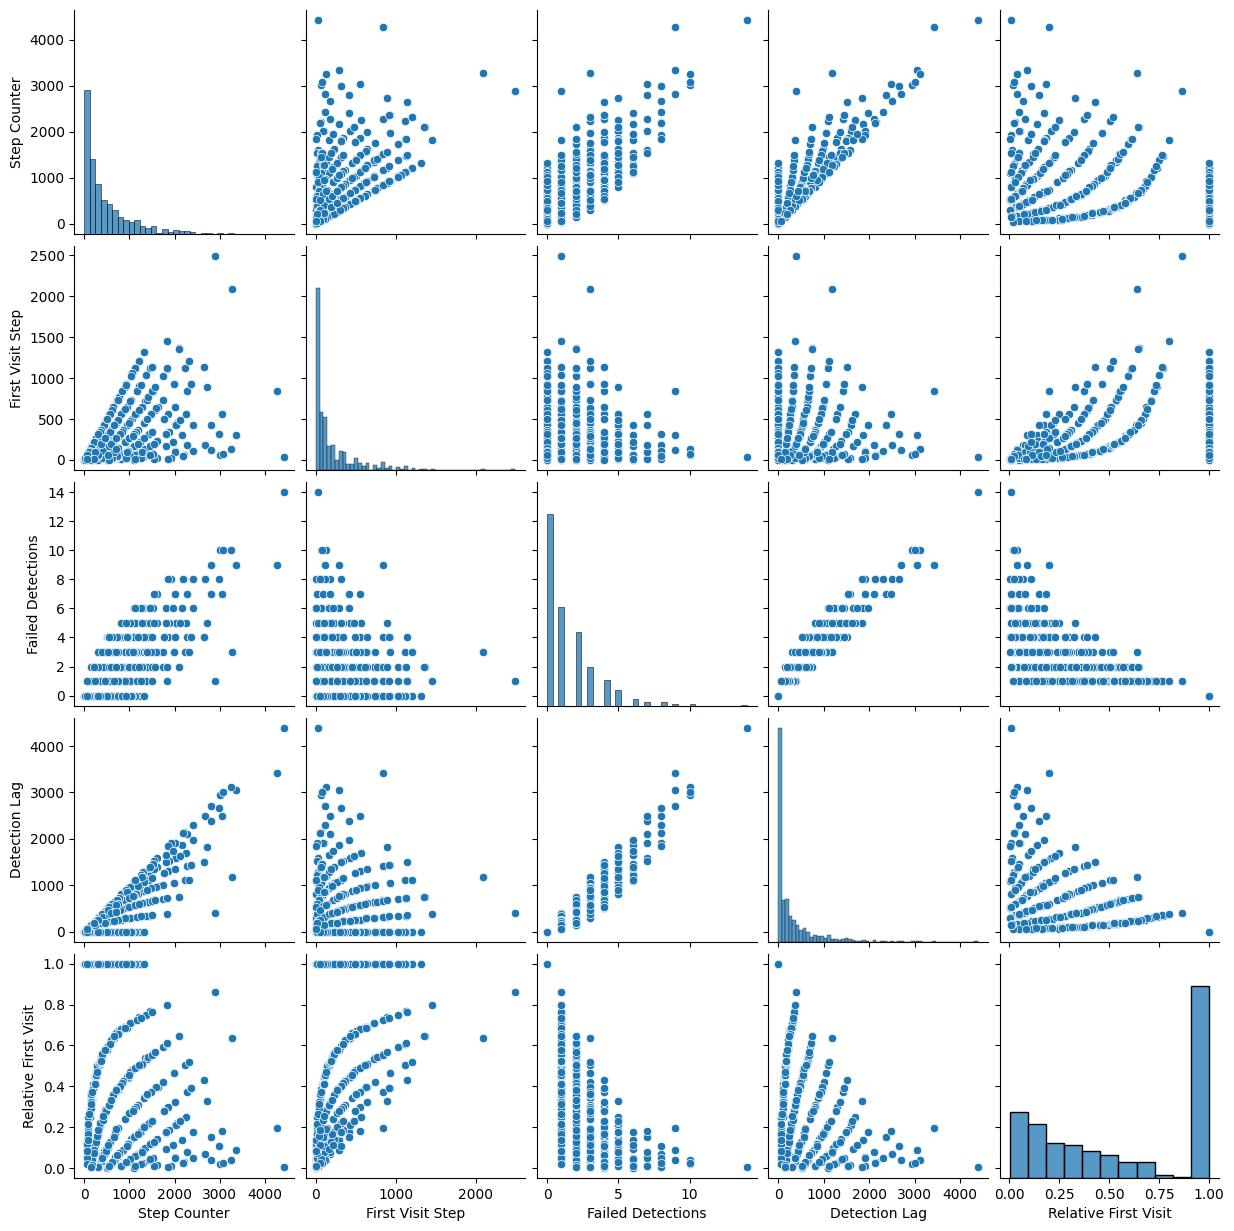

In [16]:
sns.pairplot(sims_df)

In [ ]:
sns.histplot()

## V1 Simulation (Fixed True Cell)

### Overview
- Same model as resampled version
- True cell is fixed across runs
- Used to analyze behavior in a single scenario

### Simulation Flow
1. Initialize and normalize POA grid
2. Set a fixed true_cell
3. Repeat:
   - Select highest POA cell
   - If cell == true cell:
     - Detect with probability POD
     - If success → stop
   - Update grid after failure

### Metrics Collected
- Step Counter (SC)
- Failed Detections (FD)
- First Visit Step (FVS)
- Relative First Visit (RFV)

### Interpretation
- Isolates behavior for a specific target location
- Useful for debugging and understanding search patterns
- Highlights how POD affects detection after reaching the true cell

### Purpose
Analyze search behavior in a controlled scenario rather than overall performance.